# Task 1 — Exploratory Data Analysis on Retail Sales

**Objective:** Perform a thorough exploratory data analysis to uncover sales patterns, customer behaviour, product performance, and actionable retail recommendations.

**Dataset:** Kaggle's *Customer Behavior and Purchase Dataset* (`retail_sales.csv`), containing 102,771 e-commerce transactions from January 2022 through December 2024.

**Tech stack:** Python, pandas, NumPy, matplotlib, seaborn, Jupyter Notebook

---

### Analysis roadmap

1. Inspect shape, data types, nulls, and duplicates.
2. Correct decimal and date fields and create analytical features.
3. Calculate mean, median, mode, and standard deviation for numerical variables.
4. Analyse monthly and quarterly revenue trends.
5. Explore age groups and gender distribution.
6. Identify best-selling products and category revenue.
7. Review numerical correlations.
8. Investigate a non-obvious seasonal volume-versus-value pattern.
9. Convert findings into specific business recommendations.
        

## 1. Setup

Run the installation cell once in a fresh Jupyter, VS Code, or Google Colab environment. A fixed visual style and output directory keep all figures reproducible.
        

In [1]:
%pip install -q pandas numpy matplotlib seaborn

Package installation cell retained for Jupyter/Colab; dependencies were already available during validation.


In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("screenshots")
OUTPUT_DIR.mkdir(exist_ok=True)

COLORS = {
    "navy": "#17324D",
    "blue": "#3978A8",
    "teal": "#2A9D8F",
    "gold": "#E9A23B",
    "coral": "#E76F51",
    "gray": "#7A8793",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 120

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print("Setup complete.")
        

Setup complete.


## 2. Load and inspect the dataset

The source CSV uses a semicolon delimiter. Initial inspection is deliberately performed before cleaning so data-type issues are visible rather than silently corrected.
        

In [3]:
candidate_paths = [
    Path("retail_sales.csv"),
    Path("data/retail_sales.csv"),
    Path("/kaggle/input/clothing-store-sales-data/EcommData_CSV.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("retail_sales.csv was not found beside the notebook or in data/.")

raw_df = pd.read_csv(data_path, sep=";")

print(f"Loaded: {data_path}")
print(f"Shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]:,} columns")
print(f"Exact duplicate rows: {raw_df.duplicated().sum():,}")

quality_report = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "null_count": raw_df.isna().sum(),
    "null_percent": raw_df.isna().mean().mul(100).round(2),
    "unique_values": raw_df.nunique(dropna=True),
})

display(raw_df.head())
display(quality_report)
        

Loaded: retail_sales.csv
Shape: 102,771 rows × 21 columns
Exact duplicate rows: 0
   Customer ID  Age Gender Item Purchased     Category Purchase Amount (USD)  \
0            1   55   Male           Belt  Accessories                  46,9   
1            1   55   Male        Sweater     Clothing                  48,1   
2            1   55   Male        Sweater     Clothing                  62,1   
3            1   55   Male           Belt  Accessories                  25,0   
4            1   55   Male        Sweater     Clothing                  89,8   

   Location Size      Color  Season Review Rating Subscription Status  \
0  Kentucky    L       Gray  Winter             5                 Yes   
1  Kentucky    L      Green  Spring             1                 Yes   
2  Kentucky    L      Green  Spring             5                 Yes   
3  Kentucky    L  Turquoise  Summer             5                 Yes   
4  Kentucky    L       Blue  Summer             5                 Yes   

### Observation

The raw dataset contains **102,771 transactions and 21 columns**, with **no missing values and no exact duplicate rows**. Two important type issues require correction: purchase amount and review rating are stored as text with comma decimals, while purchase date is also stored as text. Correcting these fields is essential before statistics or time-series analysis.
        

## 3. Data preparation and feature engineering

Column names are standardised to snake case, European decimal commas are converted to decimal points, and purchase dates are parsed using day-first format. Month, quarter, and age-group fields are then derived for analysis.
        

In [4]:
df = raw_df.copy()
df.columns = (
    df.columns.str.strip().str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

df["purchase_amount_usd"] = pd.to_numeric(
    df["purchase_amount_usd"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce",
)
df["review_rating"] = pd.to_numeric(
    df["review_rating"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce",
)
df["purchase_date"] = pd.to_datetime(df["purchase_date"], dayfirst=True, errors="coerce")

df = df.dropna(subset=["purchase_amount_usd", "review_rating", "purchase_date"])
df = df.drop_duplicates().reset_index(drop=True)

df["year"] = df["purchase_date"].dt.year
df["month_start"] = df["purchase_date"].dt.to_period("M").dt.to_timestamp()
df["quarter_start"] = df["purchase_date"].dt.to_period("Q").dt.start_time
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 24, 34, 44, 54, 64, 100],
    labels=["18–24", "25–34", "35–44", "45–54", "55–64", "65+"],
)

print(f"Analysis-ready shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"Date range: {df['purchase_date'].min():%d %b %Y} to {df['purchase_date'].max():%d %b %Y}")
print(f"Remaining nulls: {int(df.isna().sum().sum()):,}")
print(f"Total revenue: ${df['purchase_amount_usd'].sum():,.2f}")
print(f"Unique customers: {df['customer_id'].nunique():,}")
        

Analysis-ready shape: 102,771 rows × 25 columns
Date range: 01 Jan 2022 to 31 Dec 2024
Remaining nulls: 0
Total revenue: $5,331,988.70
Unique customers: 3,900


### Observation

The prepared dataset retains all **102,771 valid transactions**, covering exactly three years from **1 January 2022 to 31 December 2024**. It represents **3,900 unique customers** and **$5.332 million** in recorded revenue. The conversion step changes only representation; it does not remove valid business records.
        

## 4. Descriptive statistics

For every original analytical numerical column, the table below reports mean, median, mode, and sample standard deviation. Binary columns such as promo use, weekend, and churn are retained; their means can be interpreted as proportions.
        

In [5]:
numerical_columns = [
    "age", "purchase_amount_usd", "review_rating", "promo_code_used",
    "previous_purchases", "weekdaynum", "weekend", "churn",
]

descriptive_statistics = pd.DataFrame({
    "mean": df[numerical_columns].mean(),
    "median": df[numerical_columns].median(),
    "mode": df[numerical_columns].mode().iloc[0],
    "standard_deviation": df[numerical_columns].std(),
}).round(2)

descriptive_statistics.to_csv("descriptive_statistics.csv", index_label="variable")
display(descriptive_statistics)

key_metrics = pd.DataFrame({
    "metric": ["Transactions", "Unique customers", "Total revenue", "Average transaction", "Median transaction"],
    "value": [len(df), df["customer_id"].nunique(), df["purchase_amount_usd"].sum(),
              df["purchase_amount_usd"].mean(), df["purchase_amount_usd"].median()],
})
key_metrics.to_csv("eda_key_metrics.csv", index=False)
display(key_metrics)
        

                     mean  median   mode  standard_deviation
age                 44.41   45.00  57.00               15.19
purchase_amount_usd 51.88   48.70 100.00               20.78
review_rating        3.85    4.50   5.00                1.50
promo_code_used      0.13    0.00   0.00                0.34
previous_purchases  33.27   35.00  48.00               12.10
weekdaynum           4.57    5.00   6.00                1.86
weekend              0.38    0.00   0.00                0.49
churn                0.07    0.00   0.00                0.26
                metric        value
0         Transactions   102,771.00
1     Unique customers     3,900.00
2        Total revenue 5,331,988.70
3  Average transaction        51.88
4   Median transaction        48.70


### Observation

The average transaction is **$51.88**, above the **$48.70 median**, indicating a modest right tail of larger purchases. Customer age averages **44.41 years** with a 15.19-year standard deviation, so the customer base spans a broad adult range. Review ratings are generally strong: the median is **4.5** and the mode is **5.0**.
        

## 5. Monthly and quarterly sales trends

Revenue is aggregated by calendar month and quarter. Using revenue rather than row counts reveals how the actual monetary value of demand changes through time.
        

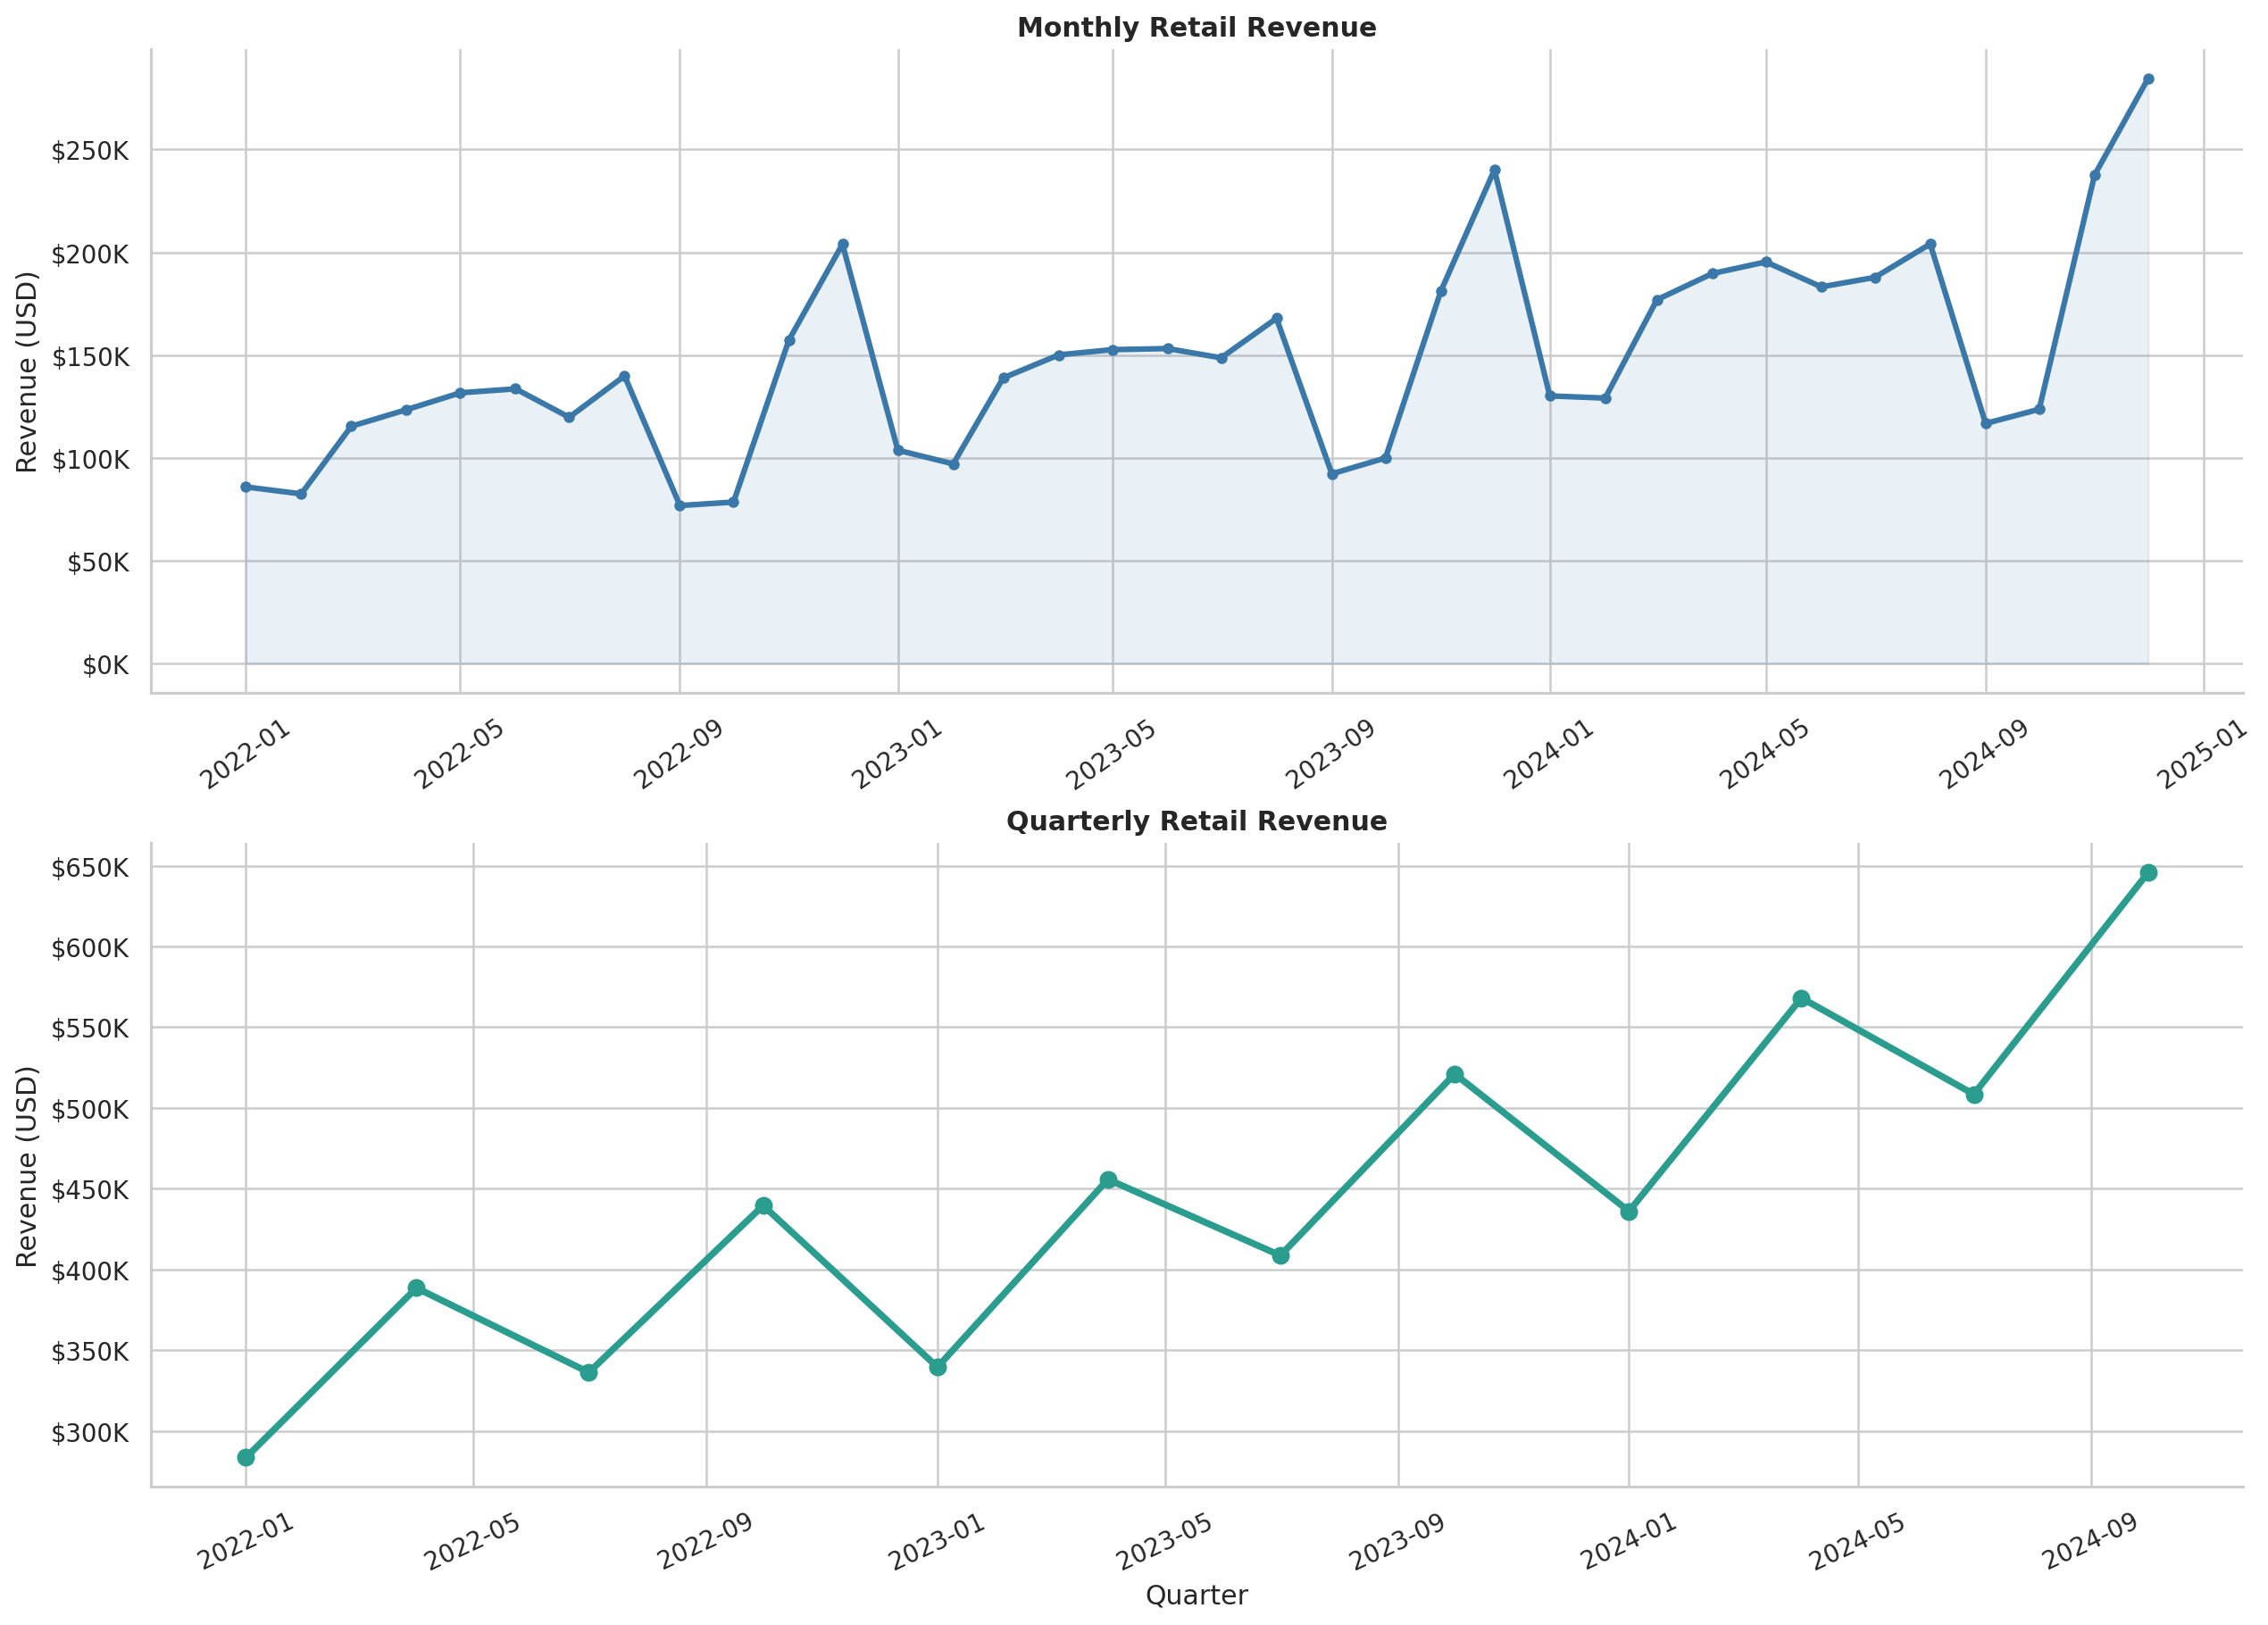

In [6]:
monthly_sales = (
    df.groupby("month_start", as_index=False)["purchase_amount_usd"].sum()
    .rename(columns={"purchase_amount_usd": "revenue"})
)
quarterly_sales = (
    df.groupby("quarter_start", as_index=False)["purchase_amount_usd"].sum()
    .rename(columns={"purchase_amount_usd": "revenue"})
)

monthly_sales.to_csv("monthly_sales.csv", index=False)
quarterly_sales.to_csv("quarterly_sales.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

axes[0].plot(monthly_sales["month_start"], monthly_sales["revenue"],
             color=COLORS["blue"], linewidth=2.5, marker="o", markersize=4)
axes[0].fill_between(monthly_sales["month_start"], monthly_sales["revenue"],
                     color=COLORS["blue"], alpha=0.10)
axes[0].set_title("Monthly Retail Revenue")
axes[0].set_ylabel("Revenue (USD)")
axes[0].tick_params(axis="x", rotation=35)

axes[1].plot(quarterly_sales["quarter_start"], quarterly_sales["revenue"],
             color=COLORS["teal"], linewidth=3, marker="o", markersize=7)
axes[1].set_title("Quarterly Retail Revenue")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Revenue (USD)")
axes[1].tick_params(axis="x", rotation=25)

for ax in axes:
    ax.yaxis.set_major_formatter(lambda value, position: f"${value/1000:,.0f}K")
    sns.despine(ax=ax)

fig.savefig(OUTPUT_DIR / "01_monthly_quarterly_sales_trends.png", dpi=180, bbox_inches="tight")
plt.show()
        

### Observation

Revenue expands materially across the three-year period. **December 2024** is the strongest month at **$284,590**, while **September 2022** is the weakest at **$76,777**. Quarterly revenue peaks in **Q4 2024 at $645,748**, compared with $283,639 in Q1 2022. The final month is more than three times the first month's revenue, supporting stronger inventory and campaign planning for late-year demand.
        

## 6. Customer demographics

Demographic distributions are calculated at the unique-customer level rather than counting repeat transactions as different people.
        

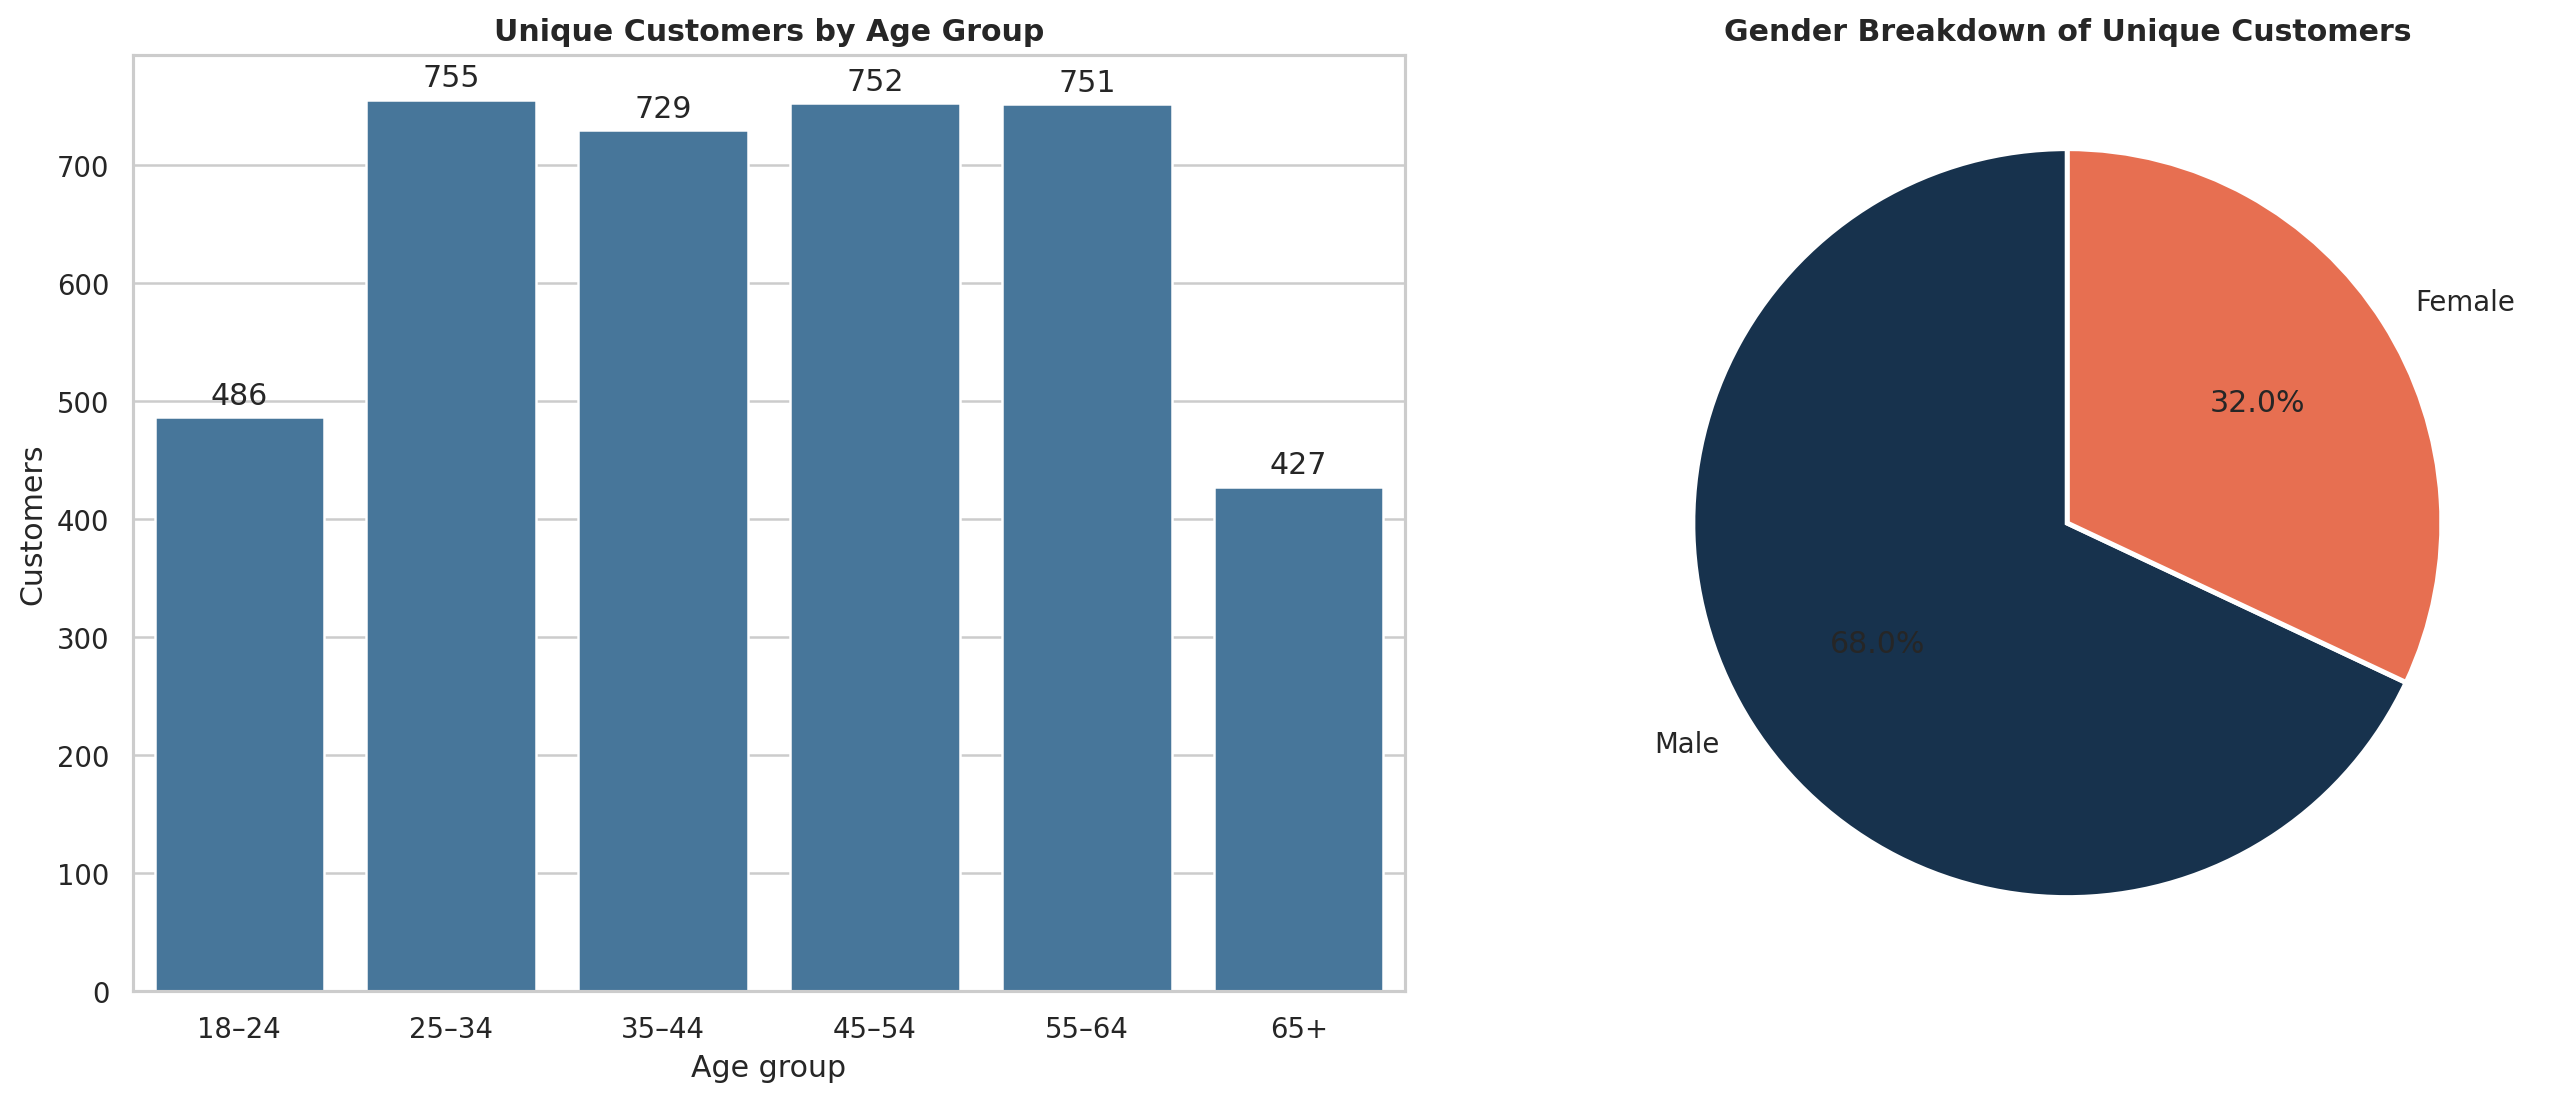

In [7]:
customers = df.sort_values("purchase_date").drop_duplicates("customer_id").copy()

age_distribution = customers["age_group"].value_counts().sort_index()
gender_distribution = customers["gender"].value_counts()

demographic_summary = pd.DataFrame({
    "age_group_customers": age_distribution,
}).reset_index(names="age_group")
demographic_summary.to_csv("customer_age_group_distribution.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

sns.barplot(x=age_distribution.index, y=age_distribution.values,
            color=COLORS["blue"], ax=axes[0])
axes[0].set_title("Unique Customers by Age Group")
axes[0].set_xlabel("Age group")
axes[0].set_ylabel("Customers")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="{:,.0f}", padding=3)

axes[1].pie(
    gender_distribution.values,
    labels=gender_distribution.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[COLORS["navy"], COLORS["coral"]],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Gender Breakdown of Unique Customers")

fig.savefig(OUTPUT_DIR / "02_customer_demographics.png", dpi=180, bbox_inches="tight")
plt.show()
        

### Observation

The customer base is concentrated between ages **25 and 64**, with each ten-year band containing roughly 729–755 unique customers. Customers aged 65+ are the smallest group at 427. The gender mix is **68% male and 32% female**. Because average transaction values are almost identical by gender (about $51.9), the revenue difference is driven mainly by customer and transaction volume rather than basket size.
        

## 7. Product and category performance

Each row records one purchased item, so transaction count is used as the unit-sales measure. The dataset contains eight distinct products; therefore, the requested “top 10” view displays all eight rather than inventing two additional products.
        

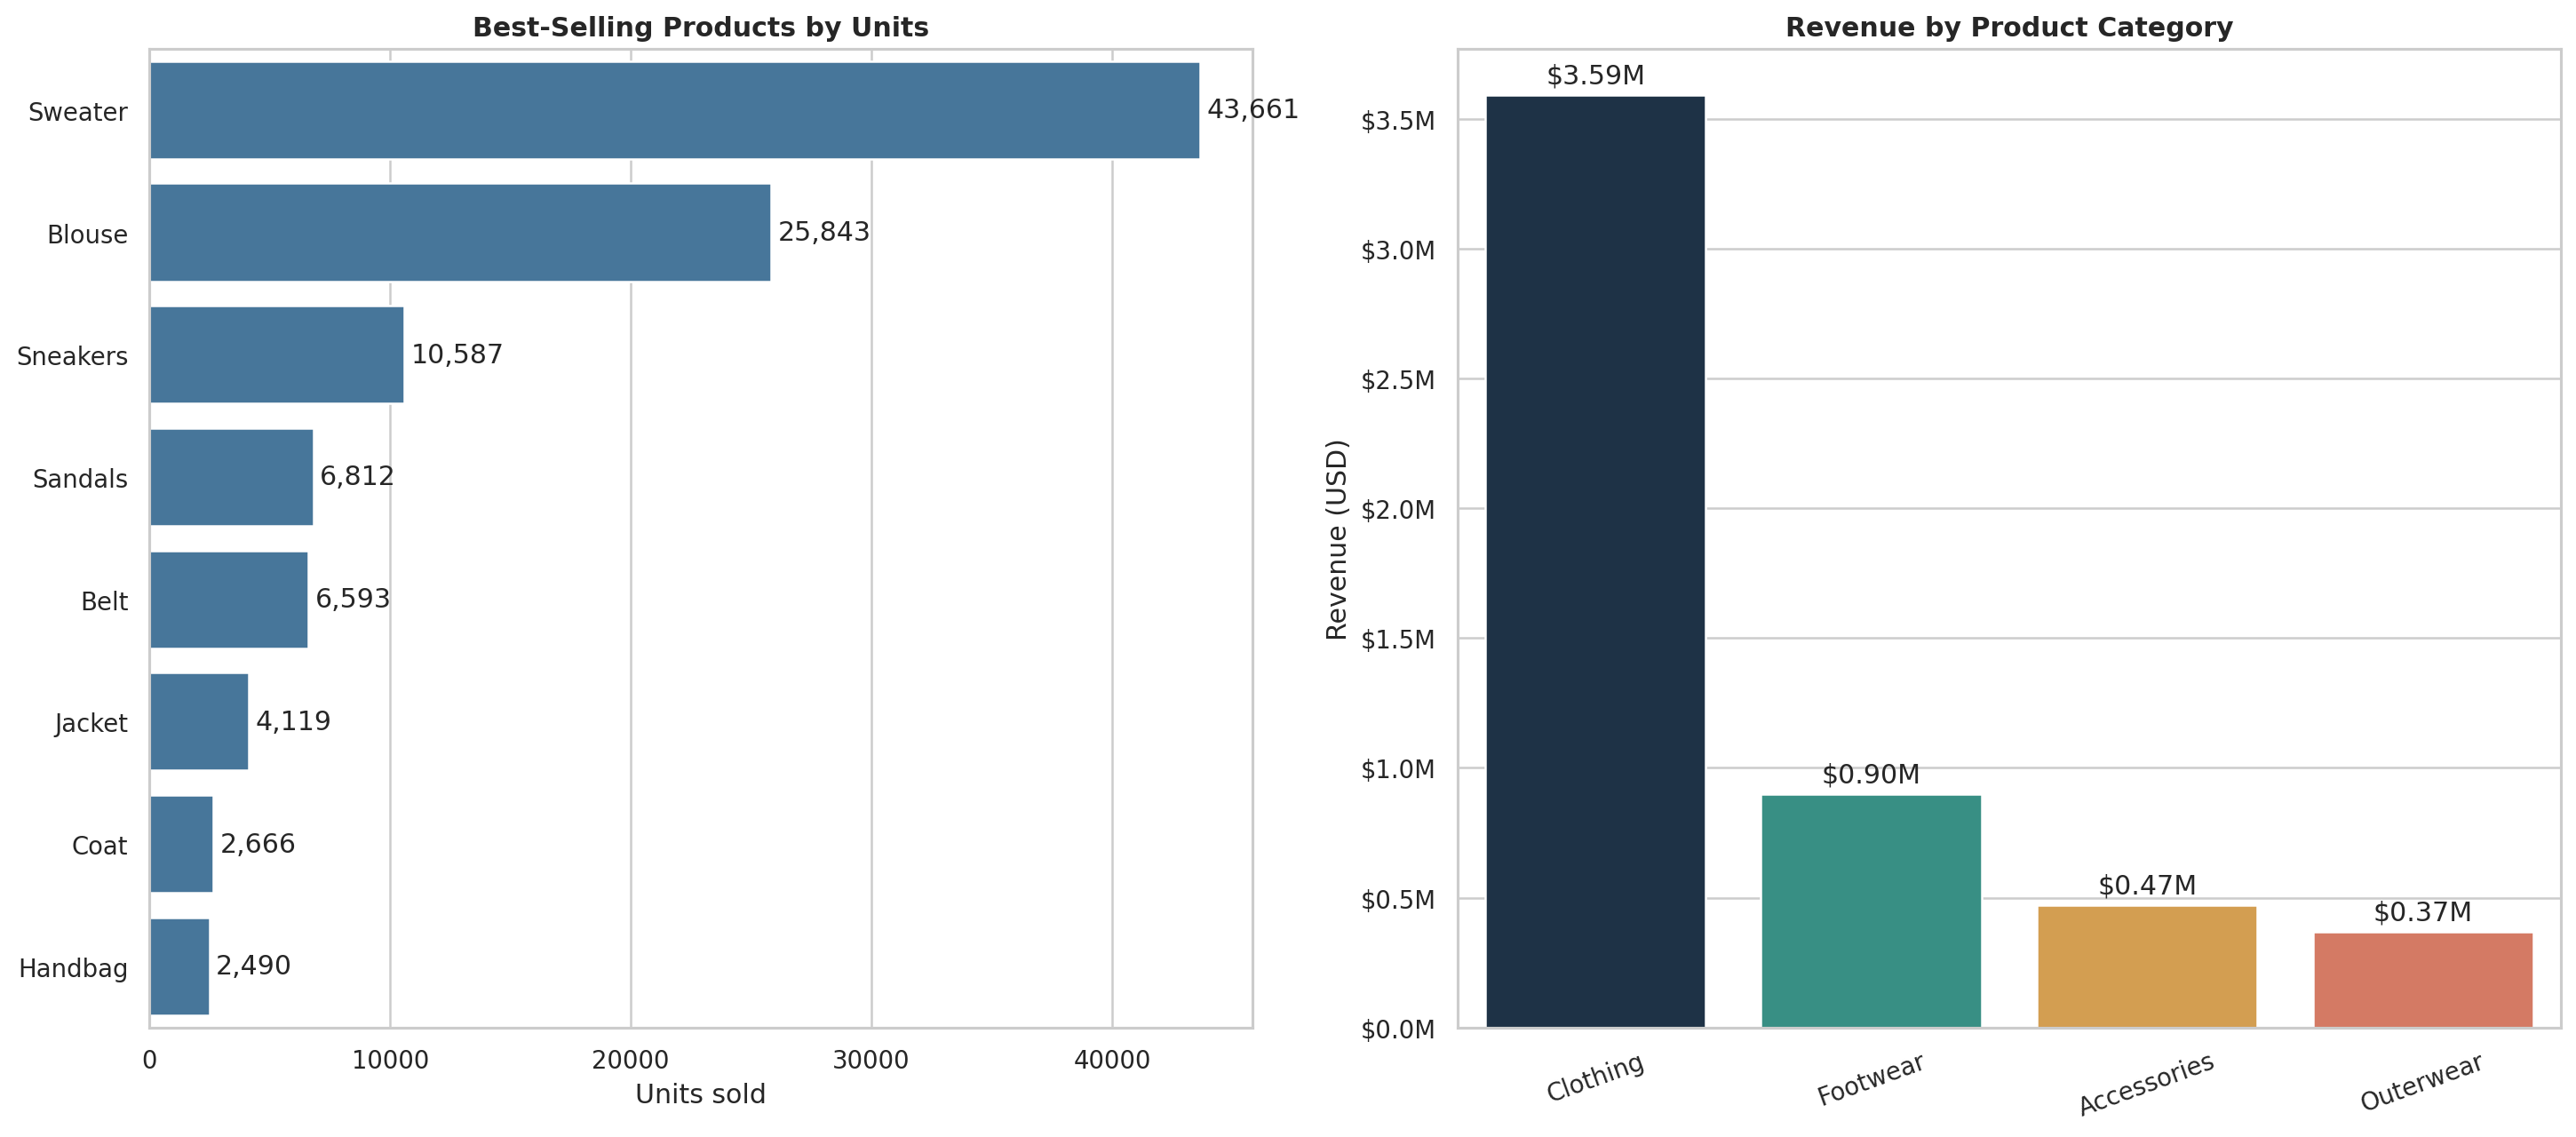

In [8]:
top_products = (
    df.groupby("item_purchased", as_index=False)
    .agg(units_sold=("item_purchased", "size"), revenue=("purchase_amount_usd", "sum"))
    .sort_values("units_sold", ascending=False)
    .head(10)
)
category_revenue = (
    df.groupby("category", as_index=False)
    .agg(revenue=("purchase_amount_usd", "sum"), transactions=("customer_id", "size"),
         average_transaction=("purchase_amount_usd", "mean"))
    .sort_values("revenue", ascending=False)
)

top_products.to_csv("top_products.csv", index=False)
category_revenue.to_csv("category_revenue.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

sns.barplot(data=top_products, y="item_purchased", x="units_sold",
            color=COLORS["blue"], ax=axes[0])
axes[0].set_title("Best-Selling Products by Units")
axes[0].set_xlabel("Units sold")
axes[0].set_ylabel("")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="{:,.0f}", padding=3)

sns.barplot(data=category_revenue, x="category", y="revenue",
            hue="category", palette=[COLORS["navy"], COLORS["teal"], COLORS["gold"], COLORS["coral"]],
            legend=False, ax=axes[1])
axes[1].set_title("Revenue by Product Category")
axes[1].set_xlabel("")
axes[1].set_ylabel("Revenue (USD)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].yaxis.set_major_formatter(lambda value, position: f"${value/1_000_000:.1f}M")
for container in axes[1].containers:
    axes[1].bar_label(container, labels=[f"${value/1_000_000:.2f}M" for value in container.datavalues], padding=3)

fig.savefig(OUTPUT_DIR / "03_product_category_performance.png", dpi=180, bbox_inches="tight")
plt.show()
        

### Observation

**Sweaters dominate product demand**, with 43,661 units and $2.289 million in revenue—about 43% of all revenue. Blouses rank second with 25,843 units. At category level, **Clothing generates $3.591 million, or 67.4% of total revenue**. The product mix is therefore highly concentrated, creating both a merchandising opportunity and an inventory-risk dependency.
        

## 8. Correlation heatmap

Pearson correlations are calculated across the original numerical fields. Identifiers and binary indicators are retained for transparency, but correlation does not imply causation.
        

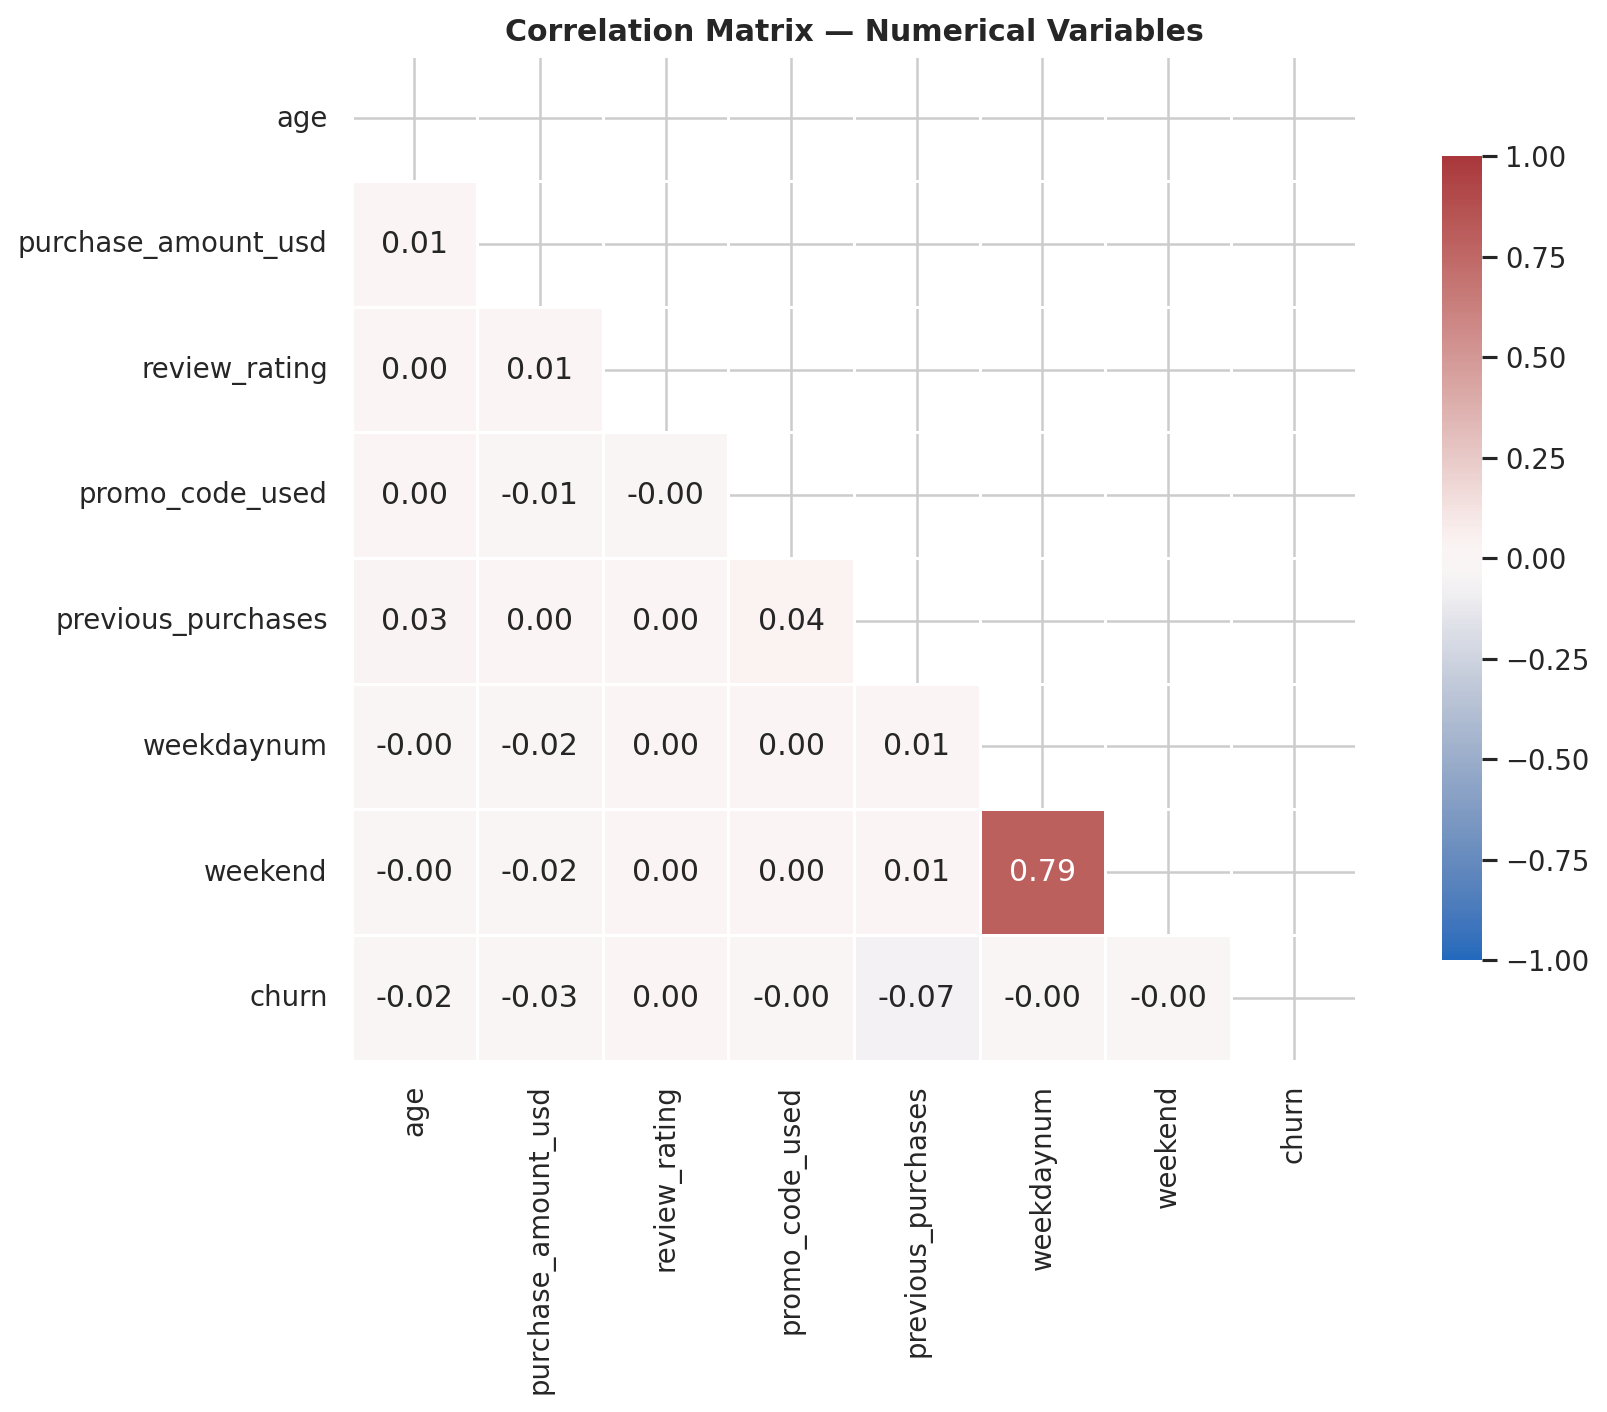

In [9]:
correlation_columns = [
    "age", "purchase_amount_usd", "review_rating", "promo_code_used",
    "previous_purchases", "weekdaynum", "weekend", "churn",
]
correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Matrix — Numerical Variables")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_correlation_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
        

### Observation

Purchase amount has **no meaningful linear relationship** with age, review rating, prior purchases, promo use, weekend status, or churn; every absolute correlation is below 0.03. This suggests basket value is more likely explained by product mix, season, or other categorical context than by a single numerical customer attribute.
        

## 9. Additional insight — seasonal volume versus transaction value

This dual-axis chart separates two drivers that total revenue can hide: transaction volume and average value per transaction.
        

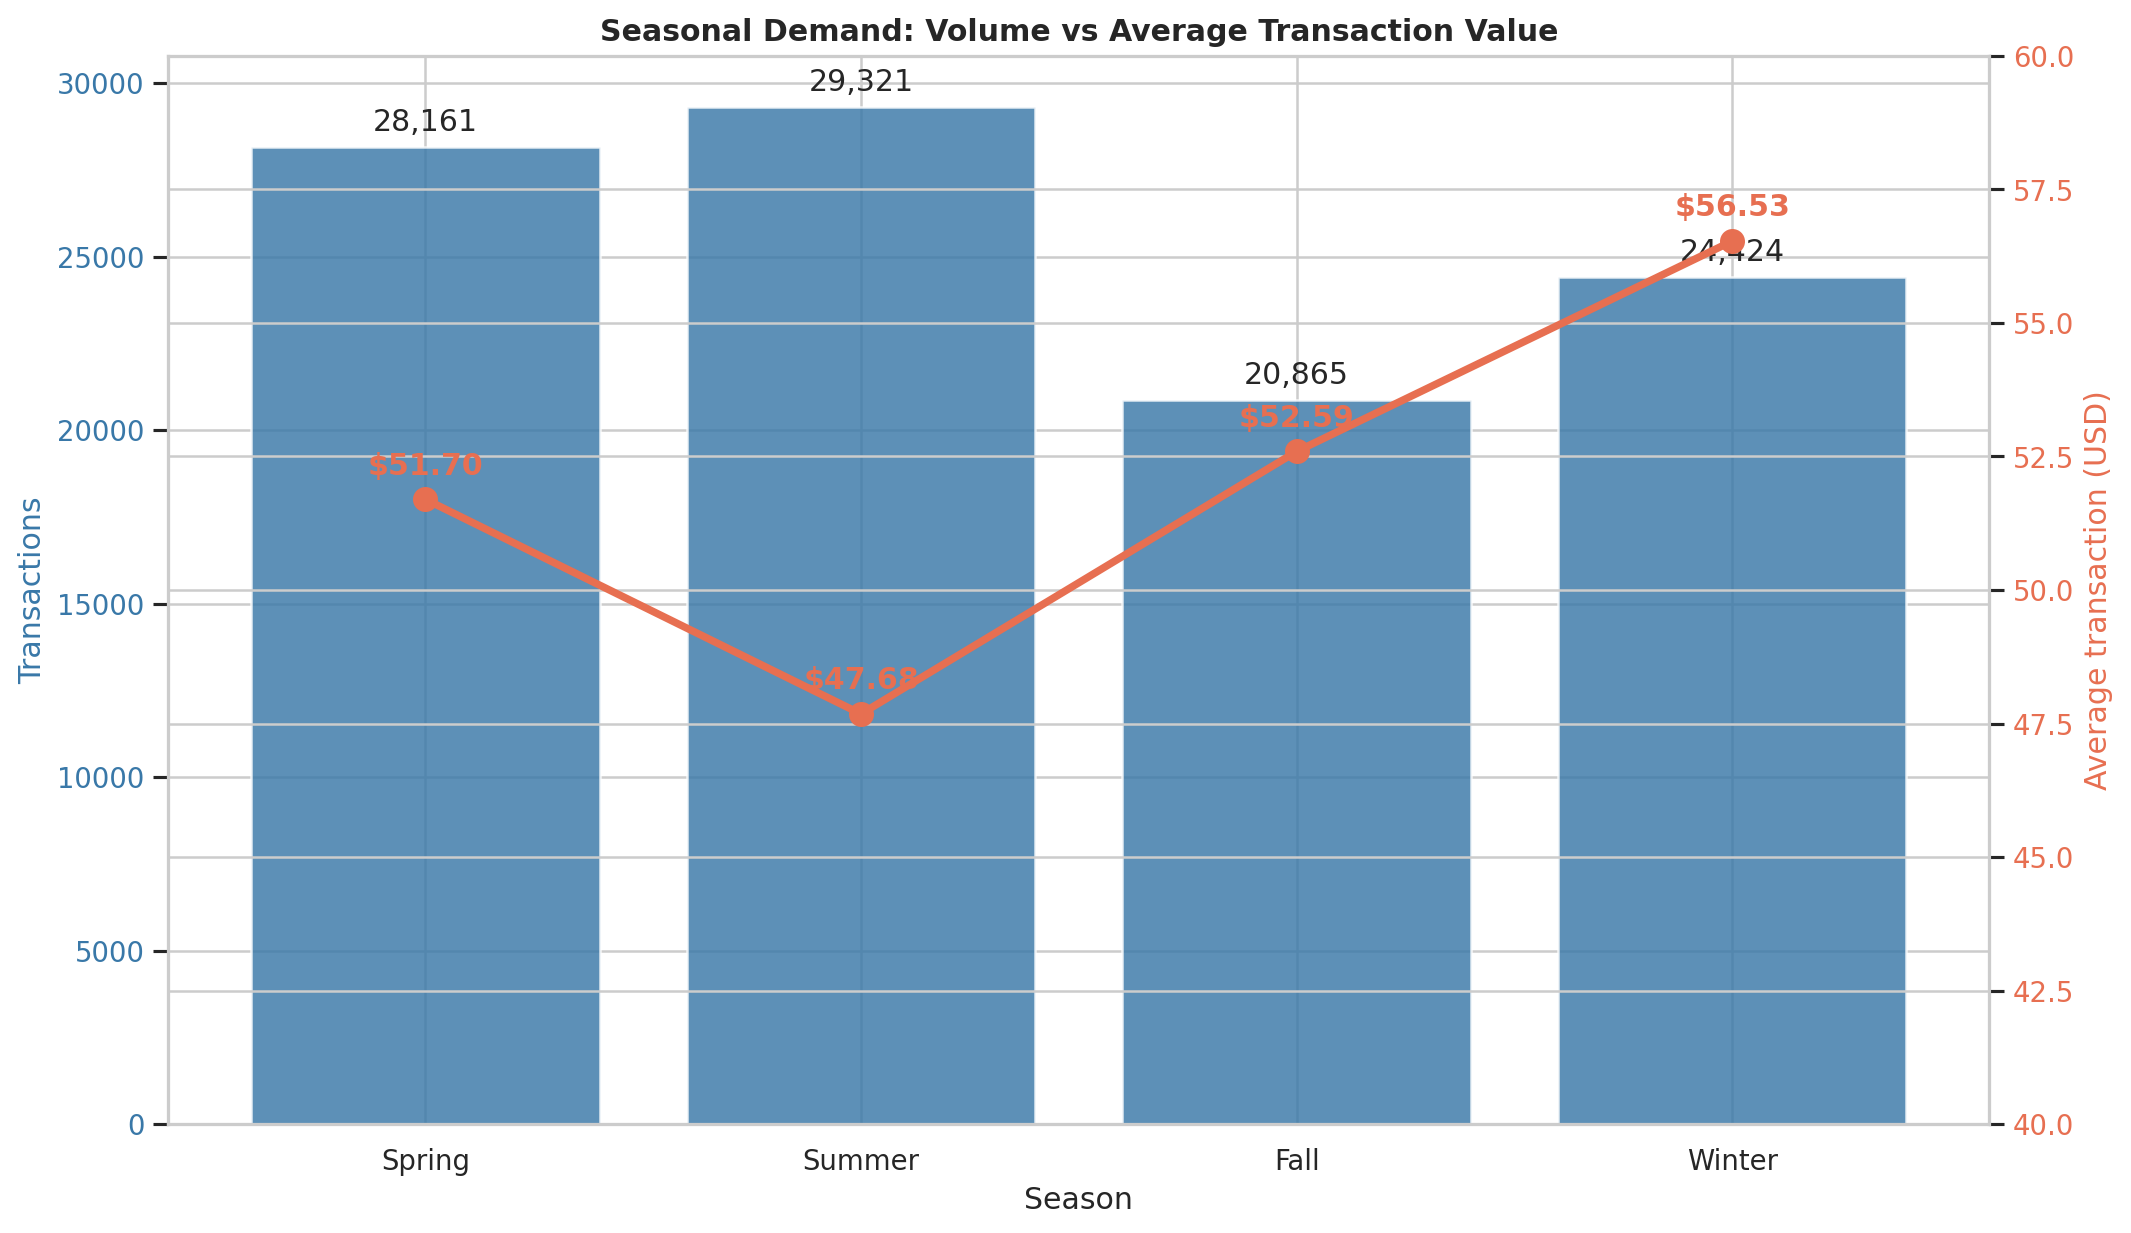

In [10]:
season_order = ["Spring", "Summer", "Fall", "Winter"]
season_summary = (
    df.groupby("season", as_index=False)
    .agg(transactions=("customer_id", "size"),
         average_transaction=("purchase_amount_usd", "mean"),
         revenue=("purchase_amount_usd", "sum"))
    .set_index("season").reindex(season_order).reset_index()
)
season_summary.to_csv("seasonal_sales_summary.csv", index=False)

fig, ax1 = plt.subplots(figsize=(12, 7))
bars = ax1.bar(season_summary["season"], season_summary["transactions"],
               color=COLORS["blue"], alpha=0.82, label="Transactions")
ax1.set_xlabel("Season")
ax1.set_ylabel("Transactions", color=COLORS["blue"])
ax1.tick_params(axis="y", labelcolor=COLORS["blue"])
ax1.bar_label(bars, fmt="{:,.0f}", padding=4)

ax2 = ax1.twinx()
ax2.plot(season_summary["season"], season_summary["average_transaction"],
         color=COLORS["coral"], linewidth=3, marker="o", markersize=9,
         label="Average transaction")
ax2.set_ylabel("Average transaction (USD)", color=COLORS["coral"])
ax2.tick_params(axis="y", labelcolor=COLORS["coral"])
ax2.set_ylim(40, 60)
for x, value in enumerate(season_summary["average_transaction"]):
    ax2.annotate(f"${value:.2f}", (x, value), xytext=(0, 10),
                 textcoords="offset points", ha="center", color=COLORS["coral"], fontweight="bold")

ax1.set_title("Seasonal Demand: Volume vs Average Transaction Value")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_seasonal_volume_value_insight.png", dpi=180, bbox_inches="tight")
plt.show()
        

### Observation

**Summer records the highest transaction volume (29,321) but the lowest average transaction value ($47.68). Winter shows the opposite pattern: only 24,424 transactions, yet the highest average value at $56.53.** This non-obvious trade-off suggests seasonal assortments or higher-priced winter items—not simply customer traffic—drive winter value.
        

## 10. Conclusion and actionable recommendations

### Summary

The dataset shows strong multi-year growth, a late-year revenue peak, substantial dependence on Clothing—especially Sweaters—and distinct seasonal volume-versus-value behaviour. Demographic differences are driven more by representation and transaction frequency than by average basket size.

### Business recommendations

1. **Prepare inventory and campaigns for Q4 demand.** Q4 2024 produced the highest quarterly revenue ($645,748), and December 2024 was the strongest month ($284,590). Increase forecasting cadence, supplier capacity, and holiday campaign readiness before the final quarter.
2. **Protect Sweater and Clothing availability while reducing concentration risk.** Sweaters alone generated $2.289 million and Clothing produced 67.4% of revenue. Maintain safety stock for proven winners, then use bundles and recommendations to cross-sell Footwear and Accessories.
3. **Use different seasonal tactics for volume and value.** Summer needs conversion and basket-building offers because traffic is high but the average transaction is only $47.68. Winter customers already spend $56.53 on average, so premium assortments and margin-focused merchandising are more appropriate than blanket discounts.
4. **Target underrepresented customer segments without changing price strategy.** Female customers represent 32% of unique customers, but their average spend is essentially the same as male customers. Customer-acquisition and personalised creative can expand female participation without relying on lower prices.
5. **Prioritise older customer retention.** Ages 55–64 generated the highest age-group revenue ($1.057 million), while customers 65+ had the highest average spend ($52.13). Loyalty communications and accessibility-focused shopping experiences could protect these valuable segments.

### Limitations

- The Kaggle dataset is designed for analytical practice and may not represent one real retailer.
- Each row is treated as one item purchase because no quantity field is provided.
- Correlations describe linear association only and do not establish causality.
- Revenue findings should be validated against profit, cost, inventory, and campaign data before operational decisions.
        

## References

- [Kaggle — Customer Behavior and Purchase Dataset](https://www.kaggle.com/datasets/timcii/clothing-store-sales-data/data)
- [pandas documentation](https://pandas.pydata.org/docs/)
- [seaborn documentation](https://seaborn.pydata.org/)
- [matplotlib documentation](https://matplotlib.org/stable/)

---

**Checklist completed:** initial inspection, descriptive statistics, monthly and quarterly trends, demographic analysis, product/category analysis, correlation heatmap, additional non-obvious visual insight, written observations after every chart, and five actionable recommendations.
        